In [3]:
from fastai.vision.all import *

In [19]:
path = untar_data(URLs.PETS)
print(output)

/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet


In [20]:
files = get_image_files(path=path/"images")

In [21]:
files

(#7391) [Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/pug_52.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/basset_hound_112.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_193.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/shiba_inu_122.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_53.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Birman_167.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/leonberger_6.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Siamese_47.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/shiba_inu_136.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/saint_bernard_139.jpg'), Path('/Users/Yashwanth.B/.fastai/data/oxford-iiit-pet/images/Birman_173.jpg'), Path('/Users/Yashwa

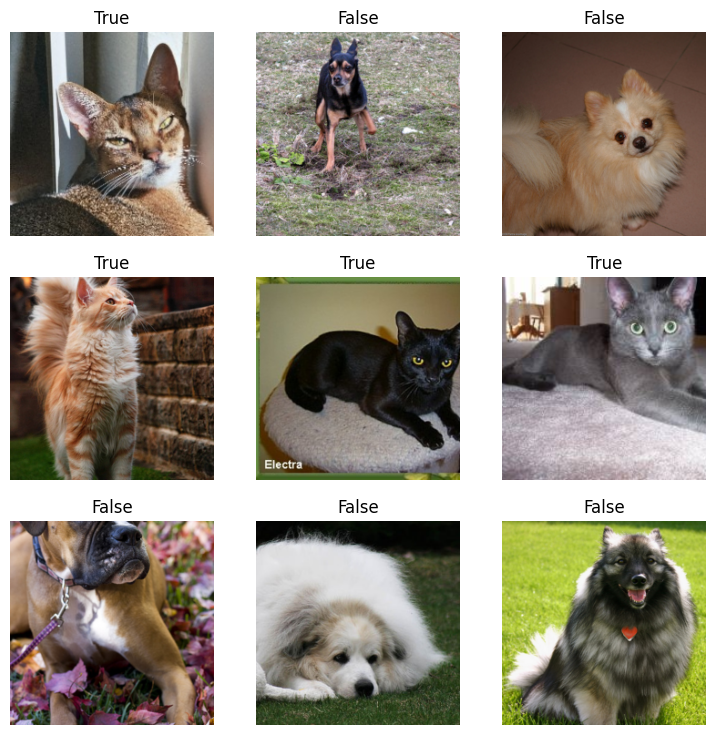

In [31]:
def label_func(f): return f[0].isupper()
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))
dls.show_batch()

<div></div>

0.0008317637839354575


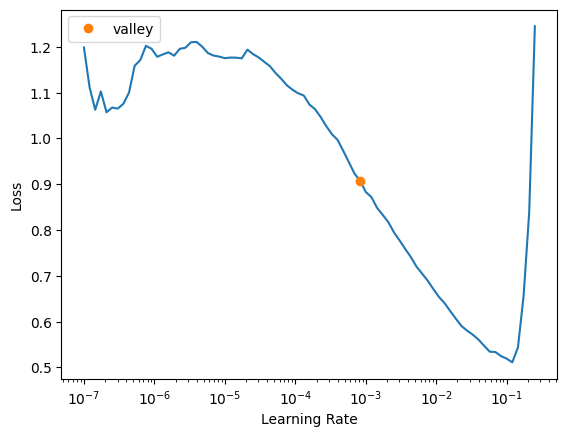

In [38]:
learner = vision_learner(dls, resnet18, metrics=[accuracy, error_rate])
plot = learner.lr_find(suggest_funcs=valley)
print(plot.valley)

In [39]:
learner.fine_tune(1, plot.valley)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.231204,0.033919,0.985115,0.014885,00:32


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.059727,0.021050,0.992558,0.007442,00:39


In [40]:
learner.predict(files[0])

('True', tensor(1), tensor([1.3884e-04, 9.9986e-01]))

In [41]:
learner.summary()

<div></div>

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      